# **ИМПОРТ БИБЛИОТЕК**

In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2D, Conv2DTranspose, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam

%matplotlib inline

# **ЗАГРУЗКА И ПРЕДОБРАБОТКА**

In [ ]:

# Загрузка оригинального датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Нормировка данных в диапазон [0, 1]
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Приведение формы к удобной для свёрточных слоев Keras (добавление канала)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Отбор только цифр «5» (согласно условию задания)
mask_train = y_train == 5
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = y_test == 5
X_test = X_test[mask_test]
y_test = y_test[mask_test]

print(f"Размер обучающей выборки пятерок: {X_train.shape}")
print(f"Размер тестовой выборки пятерок: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер обучающей выборки пятерок: (5421, 28, 28, 1)
Размер тестовой выборки пятерок: (892, 28, 28, 1)


# **ОТБОР 10 "КРАСИВЫХ" ПЯТЕРОК И ФОРМИРОВАНИЕ ДАТАСЕТА**

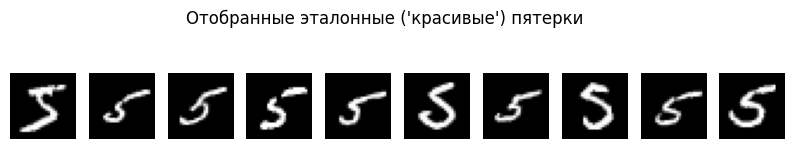

In [ ]:

# Отбираем первые 10 пятерок из выборки в качестве эталонных ("красивых")
beautiful_indexes = [0, 1, 2, 3, 4, 7, 9, 11, 12, 13]
beautiful_fives = X_train[beautiful_indexes]

# Визуализируем выбранные эталоны для наглядности
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(beautiful_fives[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Отобранные эталонные ('красивые') пятерки")
plt.show()

# Создаем массив случайных меток из красивого набора для каждого объекта выборки
np.random.seed(42) # Фиксация генератора для воспроизводимости
random_beautiful_indices = np.random.choice(len(beautiful_fives), size=len(X_train))
y_train_beautiful = beautiful_fives[random_beautiful_indices]

# То же самое делаем для тестовой выборки
random_beautiful_indices_test = np.random.choice(len(beautiful_fives), size=len(X_test))
y_test_beautiful = beautiful_fives[random_beautiful_indices_test]

# **АРХИТЕКТУРА АВТОКОДИРОВЩИКА**

In [ ]:

# Входной слой
encoder_input = Input(shape=(28, 28, 1), name="Input")

# Энкодер (Сжатие признаков)
x = Conv2D(32, (3, 3), padding='same', activation='relu')(encoder_input)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), padding='same', strides=2, activation='relu')(x) # -> 14x14
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), padding='same', strides=2, activation='relu')(x) # -> 7x7
x = BatchNormalization()(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
latent = Dense(32, activation='relu', name="Latent_Space")(x) # Латентное пространство

# Декодер (Восстановление в красивую пятерку)
x = Dense(7 * 7 * 64, activation='relu')(latent)
x = Reshape((7, 7, 64))(x)

x = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x) # -> 14x14
x = BatchNormalization()(x)
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(x) # -> 28x28
x = BatchNormalization()(x)

# Итоговый слой
decoder_output = Conv2D(1, (3, 3), padding='same', activation='sigmoid', name="Output")(x)

# Сборка модели
autoencoder = Model(encoder_input, decoder_output, name="Pro_Autoencoder")
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Проверка совпадения размеров входа и выхода (Пункт 3 задания)
print(f"\nСовпадение размеров входа и выхода: {autoencoder.input_shape[1:] == autoencoder.output_shape[1:]}")
print(f"Размер входа: {autoencoder.input_shape[1:]} | Размер выхода: {autoencoder.output_shape[1:]}\n")


Совпадение размеров входа и выхода: True
Размер входа: (28, 28, 1) | Размер выхода: (28, 28, 1)



# **ОБУЧЕНИЕ МОДЕЛИ**

In [ ]:

print("Старт обучения...")
history = autoencoder.fit(
    X_train, y_train_beautiful, # Обучаем преобразовывать X_train в красивые пятерки
    epochs=15,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test, y_test_beautiful),
    verbose=1
)

# Проверка выполнения условия по ошибке MSE
final_loss = history.history['loss'][-1]
print('\n==================================================')
print(f"Итоговая ошибка MSE на обучении: {final_loss:.5f}")
if final_loss < 0.05:
    print("Успех! Условие задания (MSE < 0.05) успешно выполнено.")
else:
    print("Ошибка выше пороговой. Попробуйте увеличить количество эпох.")
print('==================================================')

Старт обучения...
Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 0.0956 - val_loss: 0.0822
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0728 - val_loss: 0.0762
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0712 - val_loss: 0.0713
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0665 - val_loss: 0.0692
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0659 - val_loss: 0.0659
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0656 - val_loss: 0.0646
Epoch 7/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0612 - val_loss: 0.0591
Epoch 8/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0583 - val_loss: 0.0591
Epoch 9/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0572 - val_loss: 0.0596
Epoch 10/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0549 - val_loss: 0.0611
Epoch 11/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0515 - val_loss: 0.0632
Epoch 12/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - 

# **ВИЗУАЛИЗАЦИЯ**

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step


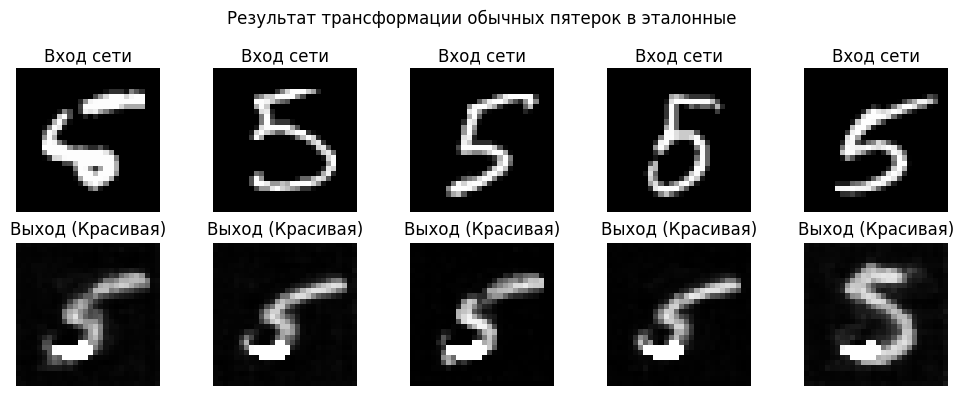

In [ ]:

# Получаем результаты трансформации для тестовых картинок
predicted_fives = autoencoder.predict(X_test)

plt.figure(figsize=(10, 4))
for i in range(5):
    # Оригинальная пятерка на входе
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Вход сети")
    plt.axis('off')

    # Пятерка, перерисованная автокодировщиком в «красивую»
    plt.subplot(2, 5, i + 6)
    plt.imshow(predicted_fives[i].reshape(28, 28), cmap='gray')
    plt.title("Выход (Красивая)")
    plt.axis('off')
plt.suptitle("Результат трансформации обычных пятерок в эталонные")
plt.tight_layout()
plt.show()